# Exchange Rate Forecasting — GARCH Volatility and Forecast Comparison

This notebook models EUR/USD return volatility with GARCH and uses the Diebold–Mariano test to compare the forecast accuracy of ARIMA, ARIMAX and XGBoost.

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error, mean_absolute_error
from xgboost import XGBRegressor

DATA_DIR = Path("../data")
master_monthly = pd.read_csv(DATA_DIR / "processed_monthly_exchange_data.csv", parse_dates=["Date"])

train_size = int(len(master_monthly) * 0.8)
train = master_monthly["EURUSD"][:train_size]
test = master_monthly["EURUSD"][train_size:]

exog = master_monthly[["DXY", "Brent_Oil", "Fed_Funds", "CPI", "Trade_Balance"]]

arima_fit = ARIMA(train, order=(0,1,1)).fit()
test_forecast = arima_fit.forecast(steps=len(test))

arimax_fit = ARIMA(train, exog=exog[:train_size], order=(0,1,1)).fit()
arimax_forecast = arimax_fit.forecast(
    steps=len(test),
    exog=exog[train_size:]
)

xgb_model = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    random_state=42
)
xgb_model.fit(exog[:train_size], train)
xgb_predictions = xgb_model.predict(exog[train_size:])

test = test.reset_index(drop=True)
test_forecast = pd.Series(test_forecast).reset_index(drop=True)
arimax_forecast = pd.Series(arimax_forecast).reset_index(drop=True)
xgb_predictions = pd.Series(xgb_predictions).reset_index(drop=True)

print("Forecast arrays aligned:", len(test), len(test_forecast), len(arimax_forecast), len(xgb_predictions))

Forecast arrays aligned: 39 39 39 39


/opt/pyvenv/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


## 1. GARCH model selection

GARCH is applied to EUR/USD log returns to model conditional volatility. The original project compared GARCH(1,1), GARCH(1,2), GARCH(2,1), and GARCH(2,2), and selected GARCH(1,1) using parsimony and BIC.

In [2]:
# Install the 'arch' package if it is not already available:
# %pip install arch

from arch import arch_model

master_monthly["EURUSD_RET"] = np.log(master_monthly["EURUSD"]).diff()
returns = master_monthly["EURUSD_RET"].dropna()
returns_scaled = returns * 100

garch_results = []
for p in range(1, 3):
    for q in range(1, 3):
        model = arch_model(returns_scaled, vol="Garch", p=p, q=q)
        res = model.fit(disp="off")
        garch_results.append({
            "Model": f"GARCH({p},{q})",
            "AIC": res.aic,
            "BIC": res.bic
        })

garch_results_df = pd.DataFrame(garch_results)
print("Sorted by AIC:")
print(garch_results_df.sort_values("AIC"))
print("\nSorted by BIC:")
print(garch_results_df.sort_values("BIC"))

Sorted by AIC:
        Model         AIC         BIC
2  GARCH(2,1)  777.028009  793.289376
0  GARCH(1,1)  777.384013  790.393107
3  GARCH(2,2)  779.028009  798.541650
1  GARCH(1,2)  779.384013  795.645380

Sorted by BIC:
        Model         AIC         BIC
0  GARCH(1,1)  777.384013  790.393107
2  GARCH(2,1)  777.028009  793.289376
1  GARCH(1,2)  779.384013  795.645380
3  GARCH(2,2)  779.028009  798.541650


## 2. Final GARCH(1,1)

1   -0.042707
2   -0.007739
3   -0.010888
4   -0.069388
5   -0.025633
Name: EURUSD_RET, dtype: float64

Missing values: 0
Length: 191


Iteration:      1,   Func. Count:      6,   Neg. LLF: 261146913.37527528
Iteration:      2,   Func. Count:     13,   Neg. LLF: 473.90070671171026
Iteration:      3,   Func. Count:     20,   Neg. LLF: 9808.8986440671
Iteration:      4,   Func. Count:     26,   Neg. LLF: 387.5891827466953
Iteration:      5,   Func. Count:     33,   Neg. LLF: 394.4409259481938
Iteration:      6,   Func. Count:     39,   Neg. LLF: 384.692106695466
Iteration:      7,   Func. Count:     44,   Neg. LLF: 384.69201847628267
Iteration:      8,   Func. Count:     49,   Neg. LLF: 384.6920064355504
Iteration:      9,   Func. Count:     53,   Neg. LLF: 384.6920064357221
Optimization terminated successfully    (Exit mode 0)
            Current function value: 384.6920064355504
            Iterations: 9
            Function evaluations: 53
            Gradient evaluations: 9
                     Constant Mean - GARCH Model Results                      
Dep. Variable:             EURUSD_RET   R-squared:                

Volatility Forecast:
h.01    1.628182
h.02    1.637397
h.03    1.645709
h.04    1.653210
h.05    1.659983
h.06    1.666102
h.07    1.671631
h.08    1.676629
h.09    1.681149
h.10    1.685237
h.11    1.688936
h.12    1.692283
Name: 191, dtype: float64


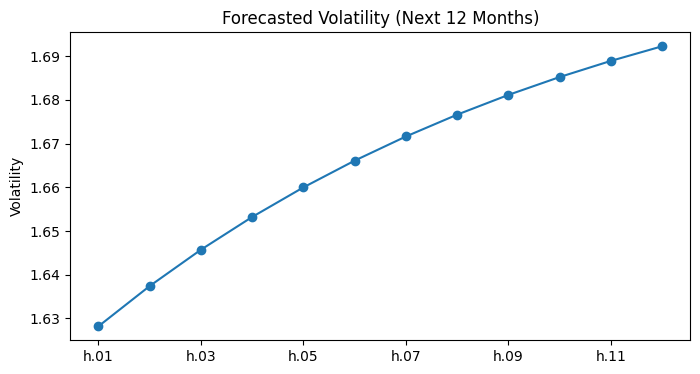

In [3]:
garch_model = arch_model(
    returns_scaled,
    vol="Garch",
    p=1,
    q=1
)
garch_res = garch_model.fit(disp="off")

print(garch_res.summary())

garch_forecast = garch_res.forecast(horizon=12)
variance_forecast = garch_forecast.variance.iloc[-1]
volatility_forecast = variance_forecast ** 0.5

print("\nVolatility Forecast:")
print(volatility_forecast)

plt.figure(figsize=(8, 4))
volatility_forecast.plot(marker="o")
plt.title("Forecasted Volatility (Next 12 Months)")
plt.ylabel("Volatility")
plt.show()

## 3. Diebold–Mariano tests

In [4]:
def diebold_mariano(y_true, y_pred1, y_pred2, h=1):
    y_true = np.array(y_true)
    y_pred1 = np.array(y_pred1)
    y_pred2 = np.array(y_pred2)

    e1 = y_true - y_pred1
    e2 = y_true - y_pred2

    d = e1**2 - e2**2
    d = d[~np.isnan(d)]

    T = len(d)
    d_mean = np.mean(d)

    def autocovariance(x, lag):
        return np.sum((x[lag:] - d_mean) * (x[:-lag] - d_mean)) / T

    gamma_0 = np.var(d, ddof=1)
    var_d = gamma_0

    for lag in range(1, h):
        gamma = autocovariance(d, lag)
        weight = 1 - lag / h
        var_d += 2 * weight * gamma

    DM_stat = d_mean / np.sqrt(var_d / T)
    p_value = 2 * (1 - stats.norm.cdf(abs(DM_stat)))

    return DM_stat, p_value

DM_arima_arimax, p_arima_arimax = diebold_mariano(
    test, test_forecast, arimax_forecast
)
DM_arima_xgb, p_arima_xgb = diebold_mariano(
    test, test_forecast, xgb_predictions
)
DM_arimax_xgb, p_arimax_xgb = diebold_mariano(
    test, arimax_forecast, xgb_predictions
)

print("ARIMA vs ARIMAX")
print("DM:", DM_arima_arimax)
print("p-value:", p_arima_arimax)

print("\nARIMA vs XGBoost")
print("DM:", DM_arima_xgb)
print("p-value:", p_arima_xgb)

print("\nARIMAX vs XGBoost")
print("DM:", DM_arimax_xgb)
print("p-value:", p_arimax_xgb)

ARIMA vs ARIMAX
DM: 7.170195846337681
p-value: 7.489564524121306e-13

ARIMA vs XGBoost
DM: 8.524643240882366
p-value: 0.0

ARIMAX vs XGBoost
DM: 9.895874839633779
p-value: 0.0


## 4. Interpretation note

The original project also compared the model RMSE values across ARIMA, ARIMAX, Random Forest, XGBoost and LSTM. The detailed model metrics are generated in the preceding notebooks. VAR is evaluated on differenced data, so its MAPE is not directly comparable with the level-based models.